# GLM-5.3-Flash on 4× CMP 170HX behind PLX switches — Morrowmake 1.6.0, TP4

| Metric | Value |
|---|---:|
| Decode, 1 user, structured / code / prose (P2P off) | **396.0 / 306.2 / 192.5 tok/s** |
| Decode, 8 users aggregate, structured (P2P off) | **798.6 tok/s** |
| Same with BAR1 peer-to-peer on | 293.4 / 228.7 / 154.3 · 450.6 tok/s |
| Morrowmake 1.6.0 TP4, P2P off, EPYC root ports | 394.0 / 377.4 / 180.5 · 797.9 tok/s |
| KV pool at 262,144 context | 1,072,150 tokens (same as Morrowmake) |

![decode vs Morrowmake](../assets/charts/2026-10-01-glm-5.3-flash-morrowmake-1.6.0-4card-tp4-vllm.png)

```bash
git clone https://github.com/Morrowmake/glm53-flash-cmp170hx-recipe && cd glm53-flash-cmp170hx-recipe && git checkout v1.6.0
```

Evidence: [`results/2026-10-01-glm-5.3-flash-morrowmake-1.6.0-4card-tp4-plx/`](../results/2026-10-01-glm-5.3-flash-morrowmake-1.6.0-4card-tp4-plx/README.md) · upstream: [Morrowmake v1.6.0](https://github.com/Morrowmake/glm53-flash-cmp170hx-recipe/tree/v1.6.0)

In [1]:
# --- Status cell ---
import os
EXPERIMENT = "2026-10-01-glm-5.3-flash-morrowmake-1.6.0-4card-tp4-plx"
RESULTS_DIR = "../results/" + EXPERIMENT
RECEIPTS = RESULTS_DIR + "/receipts"
LIVE = False  # True sends the final request to the endpoint in GLM_URL (an OpenAI-compatible /v1 base)
ENDPOINT_ENV_VAR = "GLM_URL"
print("LIVE =", LIVE, "| receipts:", RECEIPTS)

LIVE = False | receipts: ../results/2026-10-01-glm-5.3-flash-morrowmake-1.6.0-4card-tp4-plx/receipts


In [2]:
# --- Helpers: receipts, tables, chart style ---
import json, csv, statistics, datetime
from IPython.display import display, Markdown
import matplotlib
import matplotlib.pyplot as plt

def receipt(*parts):
    with open("/".join([RECEIPTS, *parts])) as f:
        return json.load(f)

def text(*parts):
    with open("/".join([RECEIPTS, *parts])) as f:
        return f.read()

def table(header, rows):
    out = ["| " + " | ".join(header) + " |", "|" + "|".join("---:" if i else "---" for i in range(len(header))) + "|"]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(out)))

# Categorical slots in fixed order (validated: CVD and normal-vision separation pass on the light surface;
# three slots sit under 3:1 contrast, so every chart is direct-labelled and backed by a table).
S = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
matplotlib.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
    "axes.titlesize": 10, "axes.titlecolor": INK, "legend.frameon": False, "lines.linewidth": 2,
})

def label_bars(ax, bars, fmt="{:.0f}", horizontal=False):
    for b in bars:
        v = b.get_width() if horizontal else b.get_height()
        if horizontal:
            ax.text(v, b.get_y() + b.get_height() / 2, " " + fmt.format(v), va="center", ha="left", color=INK2, fontsize=8)
        else:
            ax.text(b.get_x() + b.get_width() / 2, v, fmt.format(v), va="bottom", ha="center", color=INK2, fontsize=7)

## 1. TL;DR

- **Measured:** Morrowmake 1.6.0 runs in `LAYOUT=tp4` on four cards behind two PLX PEX 8747 switches (two per switch, all Gen2 x16) on a dual-socket Broadwell Xeon. The KV pool matches Morrowmake's exactly.
- **Measured:** with peer-to-peer off (the recipe default), structured decode matches Morrowmake's EPYC numbers (396.0 vs 394.0 tok/s for one user, 798.6 vs 797.9 for eight). Prose is +6.6% / −5.3%; code is −18.9% for one user and +5.4% for eight.
- **Measured:** BAR1 peer-to-peer works here (byte-exact on all 12 card pairs, 5.79 GB/s) but slows TP4 decode: each step takes ~35% longer, single-user decode drops 20–26% and eight-user 38–48%. Morrowmake measured +11% from P2P on EPYC root ports.
- **Inferred:** TP4 decode is dozens of small all-reduces per step; card-to-card over BAR1 across PLX switches and an older root complex is slower for those than the host shared-memory path (`HOSTSHM`) the engine picks with P2P off. Serve this topology with P2P off. Card-to-card copy and all-reduce measurements: [4-card BAR1 P2P notebook](2026-10-01-cmp170hx-4card-bar1-p2p-plx-cuda.ipynb).
- **Measured:** the fastest variant is P2P off + replicated embedding (398.4 / 307.3 / 192.9 tok/s for one user, 812.0 for eight) at the cost of 6% of the KV pool.

In [3]:
pins = {
    "recipe": "Morrowmake/glm53-flash-cmp170hx-recipe @ a242b4fc53 (v1.6.0); start.sh: --gpus all -> --device nvidia.com/gpu=all (LXC/CDI)",
    "engine image": "ghcr.io/morrowmake/vllm-cmp170hx@sha256:cc26c8abb63953a37c6c1861cadc9188e99c1cceab403600b5822740f3a82ae0",
    "vLLM fork": "v0.30.1rc1.dev301+g3a2bf16da",
    "target": "canada-quant/GLM-5.3-Flash-W4A16-MTP @ 5723f4d02a (W4A16)",
    "drafter": "incoai/GLM-5.3-Flash-DFlash2 @ bf582e4eac, adaptive depth up to 7 (CC BY-NC-ND 4.0: benchmark only)",
    "driver": "615.71.09 open; cmpunlocker @ 88e39ce + rebar-serialize + 4 BAR1 P2P patches",
    "host": "Proxmox VE 9.2, kernel 7.0.2-6-pve; server in a privileged LXC sharing the host driver",
    "topology": "TP4, 4 × Gen2 x16, 2 cards per PLX PEX 8747, all on one CPU socket, 180 W cap",
    "context": "262,144 tokens",
}
table(["pin", "value"], pins.items())

| pin | value |
|---|---:|
| recipe | Morrowmake/glm53-flash-cmp170hx-recipe @ a242b4fc53 (v1.6.0); start.sh: --gpus all -> --device nvidia.com/gpu=all (LXC/CDI) |
| engine image | ghcr.io/morrowmake/vllm-cmp170hx@sha256:cc26c8abb63953a37c6c1861cadc9188e99c1cceab403600b5822740f3a82ae0 |
| vLLM fork | v0.30.1rc1.dev301+g3a2bf16da |
| target | canada-quant/GLM-5.3-Flash-W4A16-MTP @ 5723f4d02a (W4A16) |
| drafter | incoai/GLM-5.3-Flash-DFlash2 @ bf582e4eac, adaptive depth up to 7 (CC BY-NC-ND 4.0: benchmark only) |
| driver | 615.71.09 open; cmpunlocker @ 88e39ce + rebar-serialize + 4 BAR1 P2P patches |
| host | Proxmox VE 9.2, kernel 7.0.2-6-pve; server in a privileged LXC sharing the host driver |
| topology | TP4, 4 × Gen2 x16, 2 cards per PLX PEX 8747, all on one CPU socket, 180 W cap |
| context | 262,144 tokens |

## 2. Results (measured)

Protocol: MiaAI-Lab `tests/bench_decode.py` @ 943912cd (the prompts Morrowmake credits), T=0, `enable_thinking=false`, 400 tokens, median of 5. Each variant is one server boot with exactly one setting changed (`env.txt` in its receipt folder). Morrowmake rows are their v1.6.0 results on EPYC root ports.

In [4]:
VARIANTS = [
    ("tp4-p2p-off", "P2P off (recipe default)"),
    ("tp4-p2p-off-repembed", "P2P off + replicated embedding"),
    ("tp4-p2p-on", "P2P on (2stage)"),
    ("tp4-p2p-on-numa1", "P2P on, pinned to cards' socket"),
    ("tp4-p2p-on-repembed", "P2P on + replicated embedding"),
    ("tp4-p2p-on-1stage", "P2P on, 1stage all-reduce"),
]
LABEL = dict(VARIANTS)
MM = {"P2P off": [394.0, 377.4, 180.5, 797.9, 683.2, 544.7], "P2P on": [437.4, 404.2, 198.6, 840.7, 769.4, 589.5]}
MM_KV = {"P2P off": 1072150, "P2P on": 1073093}
PROMPTS = ("structured", "coding", "prose")
D, STEP, ACC, POS, KV = {}, {}, {}, {}, {}
for k, _ in VARIANTS:
    D[k], STEP[k], ACC[k] = [], {}, {}
    for c in (1, 8):
        for p in PROMPTS:
            r = receipt(k, f"decode-{p}-c{c}.json")
            D[k].append(r["tok_s_median"] if c == 1 else r["aggregate_tok_s_median"])
            STEP[k][(p, c)] = r["decode_ms_per_draft_step_median"]
            ACC[k][(p, c)] = r["accepted_per_step_median"]
            if c == 1:
                POS.setdefault(k, {})[p] = r["runs"][0]["spec"]["pos"]
    KV[k] = int(text(k, "kv-pool.txt").splitlines()[0].split(":")[1].split("tokens")[0].strip().replace(",", ""))
rows = [[LABEL[k], " / ".join(f"{v:.1f}" for v in D[k][:3]), " / ".join(f"{v:.1f}" for v in D[k][3:]),
         f"{STEP[k][('structured', 1)]:.1f}", f"{ACC[k][('structured', 1)]:.2f}", f"{KV[k]:,}"] for k, _ in VARIANTS]
rows += [[f"*Morrowmake 1.6.0, {m} (EPYC)*", " / ".join(f"{v:.1f}" for v in MM[m][:3]), " / ".join(f"{v:.1f}" for v in MM[m][3:]), "—", "—", f"{MM_KV[m]:,}"] for m in MM]
table(["TP4 variant", "1 user tok/s (struct / code / prose)", "8 users aggregate tok/s", "ms per step (1 user, struct)", "accepted per step", "KV pool"], rows)

| TP4 variant | 1 user tok/s (struct / code / prose) | 8 users aggregate tok/s | ms per step (1 user, struct) | accepted per step | KV pool |
|---|---:|---:|---:|---:|---:|
| P2P off (recipe default) | 396.0 / 306.2 / 192.5 | 798.6 / 720.0 / 515.6 | 19.4 | 6.69 | 1,072,150 |
| P2P off + replicated embedding | 398.4 / 307.3 / 192.9 | 812.0 / 721.9 / 518.6 | 19.3 | 6.69 | 1,005,199 |
| P2P on (2stage) | 293.4 / 228.7 / 154.3 | 450.6 / 377.9 / 319.6 | 26.1 | 6.69 | 1,072,150 |
| P2P on, pinned to cards' socket | 294.2 / 228.9 / 154.5 | 452.4 / 381.5 / 320.3 | 26.1 | 6.69 | 1,073,093 |
| P2P on + replicated embedding | 296.0 / 230.4 / 155.3 | 453.2 / 381.0 / 321.4 | 25.9 | 6.69 | 1,006,142 |
| P2P on, 1stage all-reduce | 214.4 / 167.9 / 109.7 | 241.6 / 205.7 / 180.8 | 35.8 | 6.69 | 1,073,093 |
| *Morrowmake 1.6.0, P2P off (EPYC)* | 394.0 / 377.4 / 180.5 | 797.9 / 683.2 / 544.7 | — | — | 1,072,150 |
| *Morrowmake 1.6.0, P2P on (EPYC)* | 437.4 / 404.2 / 198.6 | 840.7 / 769.4 / 589.5 | — | — | 1,073,093 |

### 2.1 Headline: this rig vs Morrowmake

Single-user stream rate and eight-user aggregate per prompt type. Exported to `assets/charts/` as the notebook's headline chart.

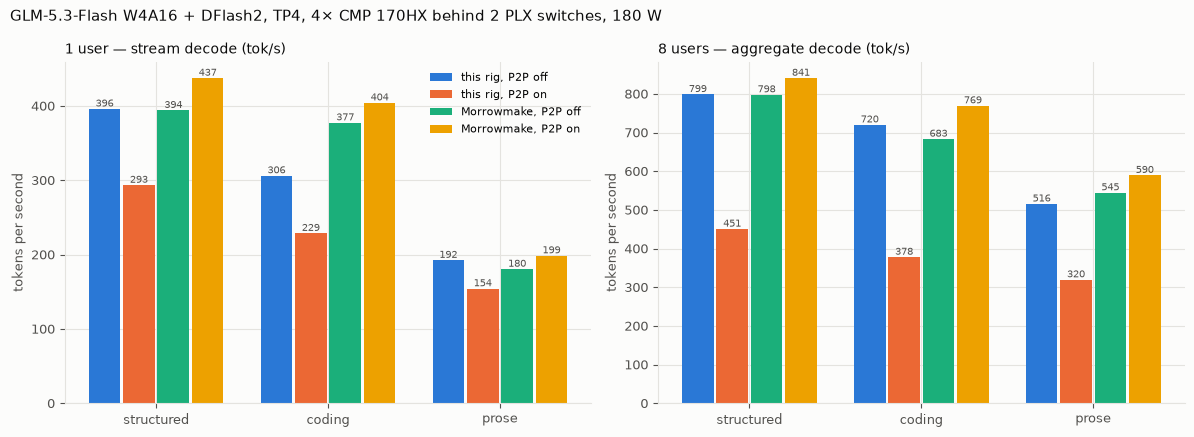

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
series = [("this rig, P2P off", D["tp4-p2p-off"], S[0]), ("this rig, P2P on", D["tp4-p2p-on"], S[1]),
          ("Morrowmake, P2P off", MM["P2P off"], S[2]), ("Morrowmake, P2P on", MM["P2P on"], S[3])]
for ax, off, title in ((axes[0], 0, "1 user — stream decode (tok/s)"), (axes[1], 3, "8 users — aggregate decode (tok/s)")):
    w = 0.2
    for i, (lab, vals, col) in enumerate(series):
        bars = ax.bar([j + (i - 1.5) * w for j in range(3)], vals[off:off + 3], w * 0.92, color=col, label=lab)
        label_bars(ax, bars)
    ax.set_xticks(range(3), PROMPTS); ax.set_title(title, loc="left"); ax.set_ylabel("tokens per second")
axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("GLM-5.3-Flash W4A16 + DFlash2, TP4, 4× CMP 170HX behind 2 PLX switches, 180 W", color=INK, x=0.01, ha="left")
fig.tight_layout()
os.makedirs("../assets/charts", exist_ok=True)
fig.savefig("../assets/charts/2026-10-01-glm-5.3-flash-morrowmake-1.6.0-4card-tp4-vllm.png", dpi=150, bbox_inches="tight"); fig.savefig("../assets/charts/2026-10-01-glm-5.3-flash-morrowmake-1.6.0-4card-tp4-vllm.svg", bbox_inches="tight")
plt.show()

### 2.2 Variant ladder (single-user structured decode)

One change per boot, ranked. Dashed lines are Morrowmake's P2P-off and P2P-on figures.

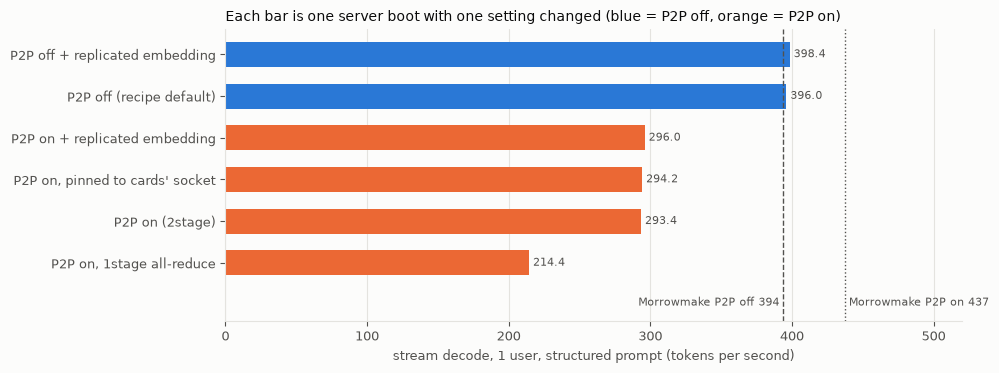

In [6]:
order = sorted(VARIANTS, key=lambda kv: D[kv[0]][0])
fig, ax = plt.subplots(figsize=(10, 3.8))
cols = [S[0] if "p2p-off" in k else S[1] for k, _ in order]
bars = ax.barh([l for _, l in order], [D[k][0] for k, _ in order], color=cols, height=0.6)
label_bars(ax, bars, "{:.1f}", horizontal=True)
for m, ls, y in (("P2P off", "--", -0.95), ("P2P on", ":", -0.95)):
    ax.axvline(MM[m][0], color=INK2, ls=ls, lw=1)
ax.text(MM["P2P off"][0], -0.95, f"Morrowmake P2P off {MM['P2P off'][0]:.0f} ", color=INK2, fontsize=8, ha="right", va="center")
ax.text(MM["P2P on"][0], -0.95, f" Morrowmake P2P on {MM['P2P on'][0]:.0f}", color=INK2, fontsize=8, ha="left", va="center")
ax.set_ylim(-1.4, len(order) - 0.4); ax.set_xlim(0, 520)
ax.set_xlabel("stream decode, 1 user, structured prompt (tokens per second)")
ax.set_title("Each bar is one server boot with one setting changed (blue = P2P off, orange = P2P on)", loc="left")
ax.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()

### 2.3 Where the time goes: milliseconds per decode step

`decode_ms_per_draft_step_median` from the receipts (a serving-cycle ratio, not a kernel timing). Acceptance per step is identical across variants, so the tok/s differences are all step time.

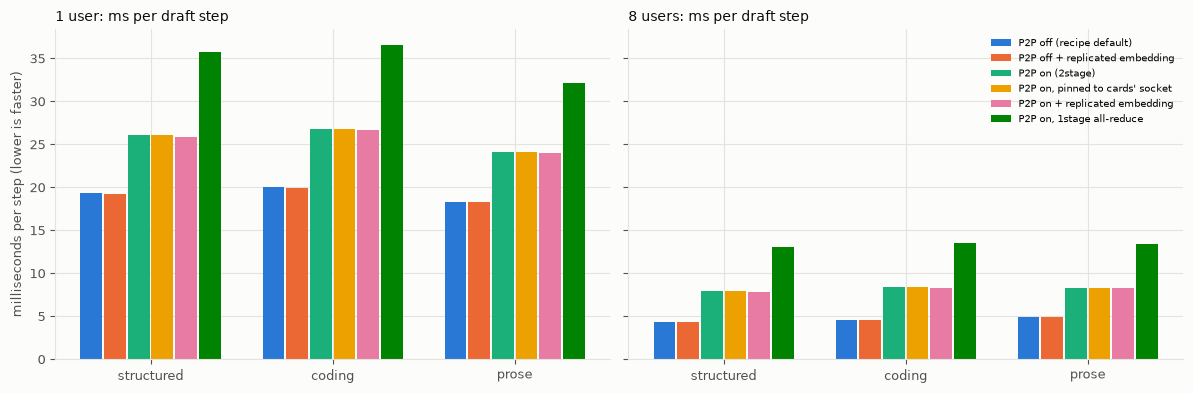

| variant | structured c=1 | coding c=1 | prose c=1 | structured c=8 | coding c=8 | prose c=8 |
|---|---:|---:|---:|---:|---:|---:|
| P2P off (recipe default) | 19.4 | 20.0 | 18.3 | 4.3 | 4.6 | 4.9 |
| P2P off + replicated embedding | 19.3 | 20.0 | 18.3 | 4.3 | 4.6 | 4.9 |
| P2P on (2stage) | 26.1 | 26.8 | 24.2 | 8.0 | 8.4 | 8.3 |
| P2P on, pinned to cards' socket | 26.1 | 26.8 | 24.1 | 8.0 | 8.4 | 8.3 |
| P2P on + replicated embedding | 25.9 | 26.6 | 24.0 | 7.9 | 8.3 | 8.2 |
| P2P on, 1stage all-reduce | 35.8 | 36.6 | 32.2 | 13.1 | 13.5 | 13.4 |

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.0), sharey=True)
for ax, c, title in ((axes[0], 1, "1 user"), (axes[1], 8, "8 users")):
    w = 0.13
    for i, (k, lab) in enumerate(VARIANTS):
        bars = ax.bar([j + (i - 2.5) * w for j in range(3)], [STEP[k][(p, c)] for p in PROMPTS], w * 0.92, color=S[i], label=lab)
    ax.set_xticks(range(3), PROMPTS); ax.set_title(f"{title}: ms per draft step", loc="left")
axes[0].set_ylabel("milliseconds per step (lower is faster)")
axes[1].legend(fontsize=7, loc="upper right")
fig.tight_layout(); plt.show()
table(["variant"] + [f"{p} c={c}" for c in (1, 8) for p in PROMPTS],
      [[LABEL[k]] + [f"{STEP[k][(p, c)]:.1f}" for c in (1, 8) for p in PROMPTS] for k, _ in VARIANTS])

### 2.4 Gap to Morrowmake, P2P off (percent)

Positive = faster than Morrowmake's EPYC figure. Single-user code is the one large gap.

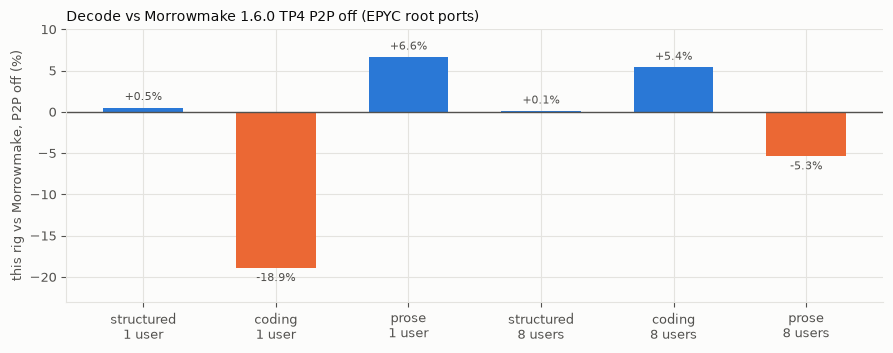

In [8]:
labels = [f"{p}\n{c} user{'s' if c > 1 else ''}" for c in (1, 8) for p in PROMPTS]
delta = [(a / b - 1) * 100 for a, b in zip(D["tp4-p2p-off"], MM["P2P off"])]
fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar(labels, delta, color=[S[0] if d >= 0 else S[1] for d in delta], width=0.6)
for b, d in zip(bars, delta):
    ax.text(b.get_x() + b.get_width() / 2, d + (0.6 if d >= 0 else -0.6), f"{d:+.1f}%", ha="center", va="bottom" if d >= 0 else "top", color=INK2, fontsize=8)
ax.axhline(0, color=INK2, lw=1); ax.set_ylim(-23, 10)
ax.set_ylabel("this rig vs Morrowmake, P2P off (%)")
ax.set_title("Decode vs Morrowmake 1.6.0 TP4 P2P off (EPYC root ports)", loc="left")
fig.tight_layout(); plt.show()

### 2.5 Scaling from 1 to 8 users

Aggregate throughput at eight users divided by the single-user stream rate. P2P on scales worse because each step's collectives grow with batch.

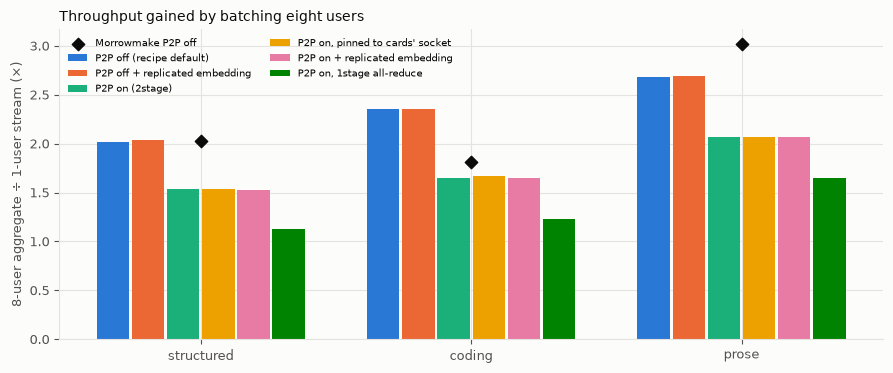

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.8))
w = 0.13
for i, (k, lab) in enumerate(VARIANTS):
    ratio = [D[k][3 + j] / D[k][j] for j in range(3)]
    bars = ax.bar([j + (i - 2.5) * w for j in range(3)], ratio, w * 0.92, color=S[i], label=lab)
mm = [MM["P2P off"][3 + j] / MM["P2P off"][j] for j in range(3)]
ax.scatter(range(3), mm, marker="D", s=40, color=INK, zorder=5, label="Morrowmake P2P off")
ax.set_xticks(range(3), PROMPTS); ax.set_ylabel("8-user aggregate ÷ 1-user stream (×)")
ax.set_title("Throughput gained by batching eight users", loc="left")
ax.legend(fontsize=7, ncol=2, loc="upper left")
fig.tight_layout(); plt.show()

### 2.6 Draft acceptance (P2P off)

Per-position acceptance of the DFlash2 draft at one user (first measured run; identical across variants). Structured text accepts almost all seven positions; prose falls off after two.

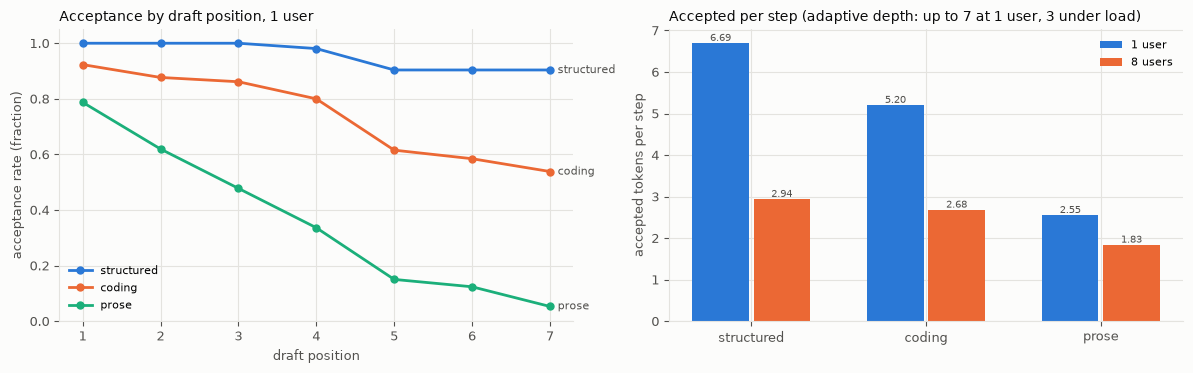

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for i, p in enumerate(PROMPTS):
    pos = POS["tp4-p2p-off"][p]
    axes[0].plot(range(1, len(pos) + 1), pos, marker="o", markersize=5, color=S[i], label=p)
    axes[0].text(len(pos) + 0.1, pos[-1], p, color=INK2, fontsize=8, va="center")
axes[0].set_xlabel("draft position"); axes[0].set_ylabel("acceptance rate (fraction)"); axes[0].set_ylim(0, 1.05)
axes[0].set_title("Acceptance by draft position, 1 user", loc="left"); axes[0].legend(fontsize=8)
w = 0.35
for j, c in enumerate((1, 8)):
    bars = axes[1].bar([i + (j - 0.5) * w for i in range(3)], [ACC["tp4-p2p-off"][(p, c)] for p in PROMPTS], w * 0.92, color=S[j], label=f"{c} user{'s' if c > 1 else ''}")
    label_bars(axes[1], bars, "{:.2f}")
axes[1].set_xticks(range(3), PROMPTS); axes[1].set_ylabel("accepted tokens per step")
axes[1].set_title("Accepted per step (adaptive depth: up to 7 at 1 user, 3 under load)", loc="left"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

### 2.7 KV pool at 262,144 context

Replicated embedding costs ~6% of the KV pool for a ≤1.7% speed gain, so the served configuration keeps it off.

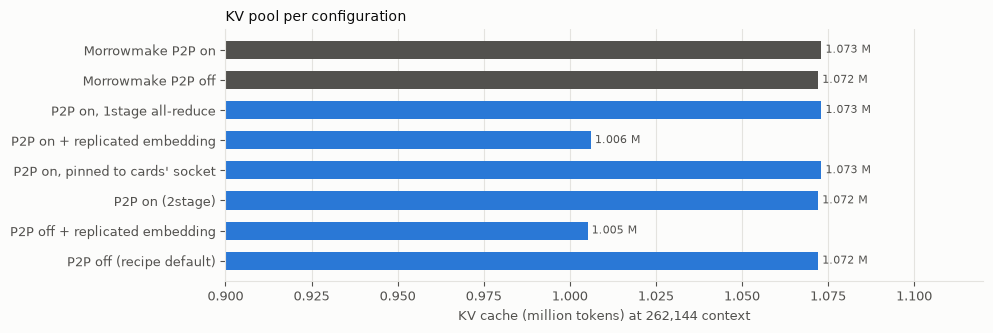

In [11]:
fig, ax = plt.subplots(figsize=(10, 3.4))
names = [LABEL[k] for k, _ in VARIANTS] + ["Morrowmake P2P off", "Morrowmake P2P on"]
vals = [KV[k] / 1e6 for k, _ in VARIANTS] + [MM_KV["P2P off"] / 1e6, MM_KV["P2P on"] / 1e6]
bars = ax.barh(names, vals, color=[S[0]] * len(VARIANTS) + [INK2, INK2], height=0.6)
label_bars(ax, bars, "{:.3f} M", horizontal=True)
ax.set_xlabel("KV cache (million tokens) at 262,144 context"); ax.set_xlim(0.9, 1.12)
ax.set_title("KV pool per configuration", loc="left"); ax.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()

## 3. Prefill and long context (final configuration: P2P off)

Cool-down gated per phase: prefill and the long-context curve each started only once all cards were under 60 °C; a guard would have stopped the run at 84 °C. Prompts are real text with a unique nonce (no prefix-cache hits). **Flag:** during the last long-context request (170,756 tokens) one card ran at 80–82 °C for 24 one-second samples, above this repository's 80 °C stop rule; that row is kept and marked.

| prompt tokens | TTFT s | prefill tok/s |
|---|---:|---:|
| 19623 | 12.01 | 1,633 |
| 19405 | 7.14 | 2,717 |
| 24600 | 9.11 | 2,701 |
| 24145 | 8.98 | 2,690 |
| 35452 | 13.11 | 2,704 |
| 26717 | 9.96 | 2,683 |

median cold prefill (excluding warmup row 1): 2,701 tok/s | Morrowmake TP4 P2P off: 2,669 tok/s on 24-38k prompts


| prompt tokens | TTFT s | decode tok/s | note |
|---|---:|---:|---:|
| 860 | 0.5 | 195.8 |  |
| 6809 | 2.6 | 171.3 |  |
| 26823 | 10.0 | 181.8 |  |
| 51851 | 20.2 | 215.6 |  |
| 103567 | 40.0 | 212.1 |  |
| 170756 | 67.1 | 163.2 | one card 80-82 °C (above stop rule) |

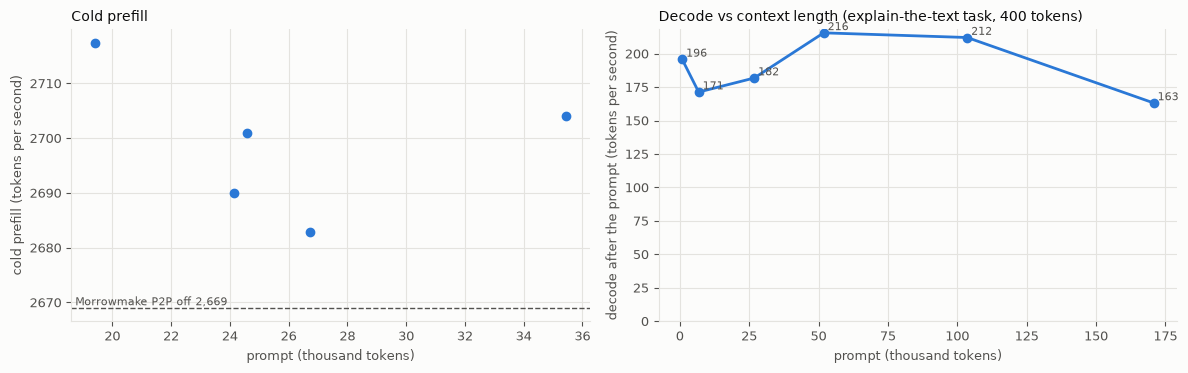

In [12]:
pf = receipt("tp4-p2p-off-final", "prefill-cold.json")["results"]
lc = receipt("tp4-p2p-off-final", "longctx-decode.json")["results"]
warm = pf[1:]  # first request = JIT warmup, excluded
table(["prompt tokens", "TTFT s", "prefill tok/s"], [[r["prompt_tokens"], f"{r['ttft_s']:.2f}", f"{r['prefill_tok_s']:,.0f}"] for r in pf])
print(f"median cold prefill (excluding warmup row 1): {statistics.median(r['prefill_tok_s'] for r in warm):,.0f} tok/s"
      " | Morrowmake TP4 P2P off: 2,669 tok/s on 24-38k prompts")
table(["prompt tokens", "TTFT s", "decode tok/s", "note"], [[r["prompt_tokens"], f"{r['ttft_s']:.1f}", f"{r['decode_tok_s']:.1f}", "one card 80-82 °C (above stop rule)" if r["prompt_tokens"] > 150000 else ""] for r in lc])
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot([r["prompt_tokens"] / 1e3 for r in warm], [r["prefill_tok_s"] for r in warm], marker="o", markersize=6, color=S[0], lw=0, label="this rig, P2P off")
axes[0].axhline(2669, color=INK2, ls="--", lw=1); axes[0].text(axes[0].get_xlim()[0], 2669, " Morrowmake P2P off 2,669", color=INK2, fontsize=8, va="bottom")
axes[0].set_xlabel("prompt (thousand tokens)"); axes[0].set_ylabel("cold prefill (tokens per second)"); axes[0].set_title("Cold prefill", loc="left")
axes[1].plot([r["prompt_tokens"] / 1e3 for r in lc], [r["decode_tok_s"] for r in lc], marker="o", markersize=6, color=S[0])
for r in lc:
    axes[1].text(r["prompt_tokens"] / 1e3, r["decode_tok_s"], f" {r['decode_tok_s']:.0f}", color=INK2, fontsize=8, va="bottom")
axes[1].set_xlabel("prompt (thousand tokens)"); axes[1].set_ylabel("decode after the prompt (tokens per second)")
axes[1].set_title("Decode vs context length (explain-the-text task, 400 tokens)", loc="left"); axes[1].set_ylim(bottom=0)
fig.tight_layout(); plt.show()

## 4. Thermals, fans and safety

Peak core temperature per run (1 s `nvidia-smi` samples), then the final run's temperature trace beside the fan controller's duty (two charts, one axis each). The repo's stop rule is 80 °C core; runs above it are flagged, not hidden.

In [13]:
def telemetry(key):
    rows = list(csv.reader(open(f"{RECEIPTS}/{key}/telemetry.csv"), skipinitialspace=True))[1:]
    by = {}
    for r in rows:
        try:
            t = datetime.datetime.strptime(r[0].split(".")[0], "%Y/%m/%d %H:%M:%S")
            by.setdefault(r[1], []).append((t, float(r[2]), float(r[4].split()[0]), float(r[5].split()[0]), float(r[8].split()[0])))
        except (ValueError, IndexError):
            pass
    return by
out = []
for k, lab in VARIANTS + [("tp4-p2p-off-final", "final P2P off: prefill + long context")]:
    try:
        by = telemetry(k)
        busy_clk = [x[3] for v in by.values() for x in v if x[4] > 50]
        out.append([lab, ", ".join(f"gpu{g} {max(x[1] for x in v):.0f}" for g, v in sorted(by.items())),
                    sum(1 for v in by.values() for x in v if x[1] >= 80), f"{min(busy_clk):.0f}" if busy_clk else "—"])
    except FileNotFoundError:
        out.append([lab, "no telemetry recorded", "—", "—"])
table(["run", "peak core °C per card", "samples ≥ 80 °C", "lowest busy SM clock (MHz)"], out)
print(text("tp4-p2p-off-final", "allreduce-backend.txt").strip())

| run | peak core °C per card | samples ≥ 80 °C | lowest busy SM clock (MHz) |
|---|---:|---:|---:|
| P2P off (recipe default) | gpu0 76, gpu1 77, gpu2 66, gpu3 70 | 0 | 1260 |
| P2P off + replicated embedding | gpu0 72, gpu1 71, gpu2 63, gpu3 66 | 0 | 1305 |
| P2P on (2stage) | gpu0 85, gpu1 82, gpu2 63, gpu3 76 | 138 | 1350 |
| P2P on, pinned to cards' socket | no telemetry recorded | — | — |
| P2P on + replicated embedding | gpu0 78, gpu1 70, gpu2 60, gpu3 69 | 0 | 1395 |
| P2P on, 1stage all-reduce | gpu0 79, gpu1 70, gpu2 58, gpu3 66 | 0 | 1410 |
| final P2P off: prefill + long context | gpu0 82, gpu1 79, gpu2 66, gpu3 74 | 24 | 1245 |

Using ['HOSTSHM', 'PYNCCL'] all-reduce backends for the TP group
Host-shm all-reduce enabled for messages <= 524288 B (world=4, threads=1024, blocks=1, two-shot >= 65536 B, DMA publish >= 262144 B, segment 7.2 MiB; setup agreed by all 4 ranks, registration one rank
all-reduce backends (in dispatch order) for group 'ep:0' out of potential backends: ['FLASHINFER_PCIE_IPC', 'FLASHINFER', 'NCCL_SYMM_MEM', 'QUICK_REDUCE', 'AITER_CUSTOM', 'HOSTSHM', 'CUSTOM', 'SYMM_ME
all-reduce backends (in dispatch order) for group 'tp:0' out of potential backends: ['FLASHINFER_PCIE_IPC', 'FLASHINFER', 'NCCL_SYMM_MEM', 'QUICK_REDUCE', 'AITER_CUSTOM', 'HOSTSHM', 'CUSTOM', 'SYMM_ME


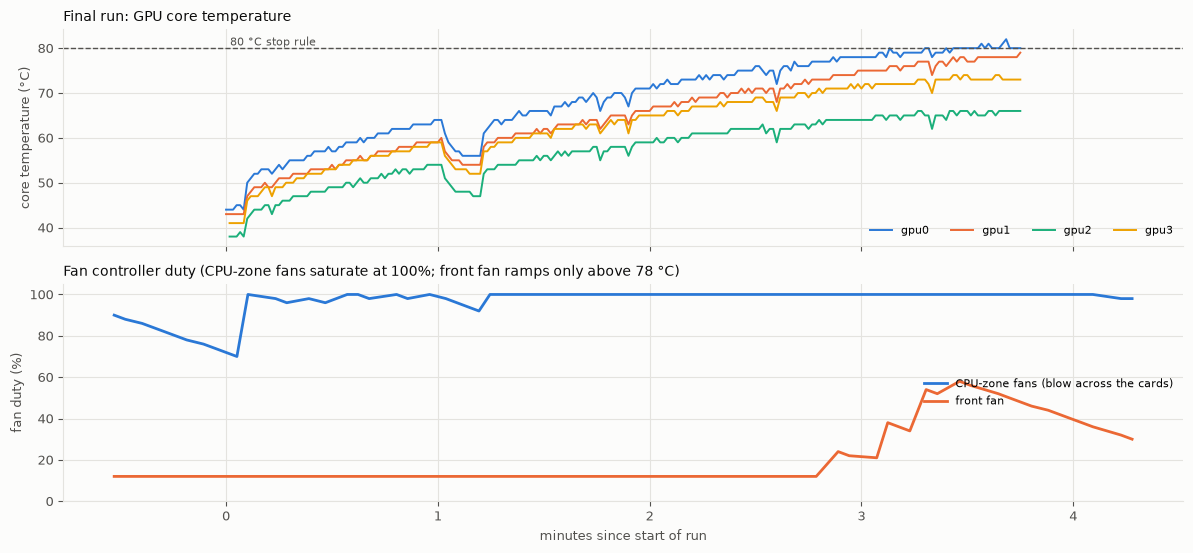

In [14]:
by = telemetry("tp4-p2p-off-final")
fan = [json.loads(l) for l in open(f"{RECEIPTS}/tp4-p2p-off-final/fan-trace.jsonl")]
t0 = min(x[0] for v in by.values() for x in v)
fig, axes = plt.subplots(2, 1, figsize=(12, 5.6), sharex=True)
for i, (g, v) in enumerate(sorted(by.items())):
    axes[0].plot([(x[0] - t0).total_seconds() / 60 for x in v], [x[1] for x in v], color=S[i], lw=1.4, label=f"gpu{g}")
axes[0].axhline(80, color=INK2, ls="--", lw=1); axes[0].text(0, 80, " 80 °C stop rule", color=INK2, fontsize=8, va="bottom")
axes[0].set_ylabel("core temperature (°C)"); axes[0].legend(fontsize=8, ncol=4, loc="lower right"); axes[0].set_title("Final run: GPU core temperature", loc="left")
ft = [(datetime.datetime.fromtimestamp(f["t"], datetime.timezone.utc).replace(tzinfo=None) - t0).total_seconds() / 60 for f in fan]  # telemetry timestamps are UTC
axes[1].plot(ft, [f["cpu_zone"] for f in fan], color=S[0], label="CPU-zone fans (blow across the cards)")
axes[1].plot(ft, [f["front"] for f in fan], color=S[1], label="front fan")
axes[1].set_ylabel("fan duty (%)"); axes[1].set_xlabel("minutes since start of run"); axes[1].set_ylim(0, 105)
axes[1].legend(fontsize=8, loc="center right"); axes[1].set_title("Fan controller duty (CPU-zone fans saturate at 100%; front fan ramps only above 78 °C)", loc="left")
fig.tight_layout(); plt.show()

## 5. Reproduce

Hardware: 4 × CMP 170HX exposing 65,536 MiB each, forced-air cooling, ~200 GB free disk for weights plus ~23 GB for the image. TP4 needs all four on x16. On a PLX / older-Xeon topology like this one, leave peer-to-peer off.

```bash
git clone https://github.com/Morrowmake/glm53-flash-cmp170hx-recipe && cd glm53-flash-cmp170hx-recipe
git checkout v1.6.0
printf 'LAYOUT=tp4\nMODELS_DIR=/path/to/models\nVLLM_ALLOW_PCIE_P2P_CUSTOM_ALLREDUCE=0\n' > .env
./install.sh          # pulls the pinned engine image
./download.sh         # target ~178 GiB + drafter ~2.2 GiB
./start.sh            # ~14 min cold boot here
./start.sh smoke
```

Bench: clone MiaAI-Lab's repo at 943912cd, set `BASE`/`MODEL` in `tests/bench_decode.py`, then run [`run_decode.sh`](../results/2026-10-01-glm-5.3-flash-morrowmake-1.6.0-4card-tp4-plx/run_decode.sh) and [`bench_long.py`](../results/2026-10-01-glm-5.3-flash-morrowmake-1.6.0-4card-tp4-plx/bench_long.py). The peer-to-peer A/B needs a driver with BAR1 peer access; the results README describes how it was built here.

## Try your own prompt

Edit `PROMPT`; with `LIVE = False` this prints the recorded structured run's response and usage instead.

In [15]:
PROMPT = "Count from 1 to 200. Output only the numbers, separated by spaces. No other text."
if LIVE:
    import urllib.request
    url = os.environ[ENDPOINT_ENV_VAR]
    body = {"model": "glm-5.3-flash", "messages": [{"role": "user", "content": PROMPT}], "max_tokens": 400, "temperature": 0}
    req = urllib.request.Request(url + "/chat/completions", json.dumps(body).encode(), {"Content-Type": "application/json"})
    resp = json.load(urllib.request.urlopen(req, timeout=600))
    print(resp["choices"][0]["message"].get("content")); print(resp["usage"])
else:
    run = receipt("tp4-p2p-off", "decode-structured-c1.json")["runs"][0]
    print(run["text"][:400]); print(run["usage"])

The user wants me to count from 1 to 200, outputting only the numbers separated by spaces, with no other text. This is a straightforward request. Let me generate the numbers 1 through 200 separated by spaces.1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 
{'prompt_tokens': 33, 'total_tokens': 433, 'completion_tokens': 400, 'completion_tokens_details': {'reasoning_tokens': 0}}


<details><summary>Appendix</summary>

- **Thinking off still thinks (measured; documented upstream).** With `chat_template_kwargs.enable_thinking=false` the model writes a short reasoning preamble into `content` before the answer. Morrowmake's how-to-use says the same, and their figures use the same prompts.
- **Drafter licence.** `incoai/GLM-5.3-Flash-DFlash2` is CC BY-NC-ND 4.0 and is used here for benchmarking only. The Apache-2.0 `canada-quant/GLM-5.3-Flash-DFlash2-G` does not load on this engine (8 full-attention layers vs 5 sliding-window): start-up stops with `indexer.k_cache: page size is not divisible by the maximum page size and cannot be padded`.
- **Excluded receipts.** The first P2P-on boot's cold prefill reached 85 °C on one card and its long-context run was cut by the temperature guard; both are kept under `tp4-p2p-on/excluded/` and not used. The NUMA-pinned run recorded no telemetry.
- **Open.** Single-user code decode is 19% under Morrowmake (306 vs 377 tok/s) at the same acceptance per step; not investigated. PP4 on this rig and quality suites are untested.
- **Licences.** Recipe MIT; drafter CC BY-NC-ND 4.0; MiaAI-Lab bench AGPL-3.0, referenced by commit, not vendored.

</details>